# YOLO inference on an image or video

## 0. Install dependencies (skip if already installed)

In [1]:
# %pip install ultralytics opencv-python numpy pandas scikit-learn scikit-image joblib matplotlib tqdm
# Note: scikit-learn should be the same version used when fog_model.pkl was saved.

## 1. Config

In [2]:
from pathlib import Path
import torch

CONFIG = {
    # ---- what to run ----
    "INPUT_PATH": r"G:\Downloads\15365456-hd_1080_1920_30fps.mp4",         # image or video file
    "MODEL_PATH": r"runs/detect/dcp1_exp1-9/weights/best.pt",   # trained YOLO weights
    "OUTPUT_DIR": "outputs",

    # ---- preprocessing (must match how the model was trained) ----
    # "auto"   -> fog classifier decides per image/frame; foggy ones get dehaze + exposure
    # "always" -> dehaze + exposure on every image/frame
    # "none"   -> raw image/frame, just resized to IMG_SIZE
    "PREPROCESS_MODE": "auto",
    "FOG_MODEL_PATH": "fog_model.pkl",      # only used when PREPROCESS_MODE == "auto"
    "APPLY_DCP": True,
    "APPLY_EXPOSURE": True,
    "IMG_SIZE": 640,

    # ---- detection ----
    "CONF": 0.25,
    "IOU": 0.7,
    "DEVICE": 0 if torch.cuda.is_available() else "cpu",

    # ---- video ----
    "FRAME_INTERVAL_SEC": 1.0,   # extract one frame every N seconds
    # "sampled": output video contains only the sampled frames (played at OUTPUT_FPS)
    # "full":    output keeps every original frame and original fps; boxes from the most
    #            recent sampled frame are held until the next one
    "VIDEO_MODE": "full",
    "OUTPUT_FPS": 1,             # only used when VIDEO_MODE == "sampled"
    "PREVIEW_FRAMES": 6,         # how many annotated frames to show in the notebook

    # ---- drawing ----
    # "original":  boxes drawn on the untouched input (scaled back from 640x640)
    # "processed": boxes drawn on the dehazed/enhanced 640x640 image the model actually saw
    "DRAW_ON": "original",
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}
VIDEO_EXTS = {".mp4", ".avi", ".mov", ".mkv", ".wmv", ".flv", ".webm", ".m4v", ".mpg", ".mpeg"}

input_path = Path(CONFIG["INPUT_PATH"])
out_dir = Path(CONFIG["OUTPUT_DIR"]); out_dir.mkdir(parents=True, exist_ok=True)

if not input_path.exists():
    raise FileNotFoundError(f"INPUT_PATH not found: {input_path}")

ext = input_path.suffix.lower()
if ext in IMAGE_EXTS:
    MEDIA_TYPE = "image"
elif ext in VIDEO_EXTS:
    MEDIA_TYPE = "video"
else:
    raise ValueError(f"Unsupported file type '{ext}'. Add it to IMAGE_EXTS or VIDEO_EXTS.")

print(f"Input : {input_path}")
print(f"Type  : {MEDIA_TYPE}")
print(f"Device: {CONFIG['DEVICE']}")

Input : G:\Downloads\15365456-hd_1080_1920_30fps.mp4
Type  : video
Device: 0


## 2. Load model (and fog classifier, if used)

In [3]:
import cv2
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from ultralytics import YOLO

model = YOLO(CONFIG["MODEL_PATH"])
class_names = model.names
print("Classes:", class_names)

fog_bundle = None
if CONFIG["PREPROCESS_MODE"] == "auto":
    if Path(CONFIG["FOG_MODEL_PATH"]).exists():
        fog_bundle = joblib.load(CONFIG["FOG_MODEL_PATH"])
        print("Loaded fog classifier")
    else:
        raise FileNotFoundError(
            f"PREPROCESS_MODE is 'auto' but {CONFIG['FOG_MODEL_PATH']} was not found. "
            "Point FOG_MODEL_PATH at the file saved by the training notebook, or set PREPROCESS_MODE to 'always' or 'none'."
        )

Classes: {0: 'Bike-car-person', 1: 'Bike', 2: 'Car', 3: 'Person'}
Loaded fog classifier


## 3. Preprocessing (copied from the training notebook)

In [4]:
from skimage import exposure, color

FEATURE_COLS = ["mean_dark_intensity", "laplacian_var", "mean_saturation"]

def dark_channel(img, patch=15):
    min_channel = np.min(img, axis=2)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (patch, patch))
    return cv2.erode(min_channel, kernel)

def estimate_fog_features(img_bgr, size=(256, 256), patch=15):
    img = cv2.resize(img_bgr, size, interpolation=cv2.INTER_AREA)
    dark = dark_channel(img, patch)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    return {
        "mean_dark_intensity": float(np.mean(dark)),
        "laplacian_var": float(cv2.Laplacian(gray, cv2.CV_64F).var()),
        "mean_saturation": float(np.mean(hsv[:, :, 1])),
    }

def is_foggy(img_bgr):
    feats = pd.DataFrame([estimate_fog_features(img_bgr)])[FEATURE_COLS]
    x = fog_bundle["scaler"].transform(feats)
    return int(fog_bundle["kmeans"].predict(x)[0]) == int(fog_bundle["fog_cluster"])

def estimate_atmospheric_light(img, dark, top_percent=0.001):
    h, w = dark.shape
    n_pixels = max(int(h * w * top_percent), 1)
    flat_dark = dark.reshape(-1)
    flat_img = img.reshape(-1, 3)
    idx = np.argpartition(flat_dark, -n_pixels)[-n_pixels:]
    brightest = idx[np.argmax(flat_img[idx].sum(axis=1))]
    return flat_img[brightest].astype(np.float64)

def guided_filter(guide, src, radius=40, eps=1e-3):
    guide = guide.astype(np.float64)
    src = src.astype(np.float64)
    mean_g = cv2.boxFilter(guide, cv2.CV_64F, (radius, radius))
    mean_s = cv2.boxFilter(src, cv2.CV_64F, (radius, radius))
    mean_gs = cv2.boxFilter(guide * src, cv2.CV_64F, (radius, radius))
    cov_gs = mean_gs - mean_g * mean_s
    mean_gg = cv2.boxFilter(guide * guide, cv2.CV_64F, (radius, radius))
    var_g = mean_gg - mean_g * mean_g
    a = cov_gs / (var_g + eps)
    b = mean_s - a * mean_g
    mean_a = cv2.boxFilter(a, cv2.CV_64F, (radius, radius))
    mean_b = cv2.boxFilter(b, cv2.CV_64F, (radius, radius))
    return mean_a * guide + mean_b

def estimate_transmission(img, A, patch=15, omega=0.95):
    normalized = img.astype(np.float64) / A
    return 1 - omega * dark_channel(normalized, patch)

def dehaze(img_bgr, patch=15, omega=0.95, t0=0.1, guide_radius=40, guide_eps=1e-3):
    img = img_bgr.astype(np.float64)
    dark = dark_channel(img, patch)
    A = estimate_atmospheric_light(img, dark)
    t = estimate_transmission(img, A, patch, omega)
    gray_guide = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY).astype(np.float64) / 255.0
    t_refined = np.clip(guided_filter(gray_guide, t, radius=guide_radius, eps=guide_eps), t0, 1.0)
    J = np.empty_like(img)
    for c in range(3):
        J[:, :, c] = (img[:, :, c] - A[c]) / t_refined + A[c]
    return np.clip(J, 0, 255).astype(np.uint8)

def enhance_exposure(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB) / 255.0
    lab = color.rgb2lab(rgb)
    l_eq = exposure.equalize_adapthist(lab[:, :, 0] / 100.0, clip_limit=0.01)
    lab[:, :, 0] = l_eq * 100.0
    rgb_eq = np.clip(color.lab2rgb(lab), 0, 1)
    return cv2.cvtColor((rgb_eq * 255).astype(np.uint8), cv2.COLOR_RGB2BGR)

S = CONFIG["IMG_SIZE"]

def preprocess(img_bgr):
    """Same steps as training: [dehaze + exposure if foggy] -> resize to SxS (squash, INTER_AREA)."""
    mode = CONFIG["PREPROCESS_MODE"]
    if mode == "always":
        apply = True
    elif mode == "auto":
        apply = is_foggy(img_bgr)
    else:
        apply = False

    out = img_bgr
    if apply:
        if CONFIG["APPLY_DCP"]:
            out = dehaze(out)
        if CONFIG["APPLY_EXPOSURE"]:
            out = enhance_exposure(out)
    out = cv2.resize(out, (S, S), interpolation=cv2.INTER_AREA)
    return out, apply

## 4. Detection + drawing helpers

In [5]:
rng = np.random.default_rng(3)
PALETTE = {i: tuple(int(v) for v in rng.integers(60, 255, 3)) for i in range(len(class_names))}

def process_frame(img_bgr):
    """Preprocess, run YOLO, return boxes in the SxS processed-image coordinate space."""
    proc, applied = preprocess(img_bgr)
    r = model.predict(proc, imgsz=S, conf=CONFIG["CONF"], iou=CONFIG["IOU"],
                      device=CONFIG["DEVICE"], verbose=False)[0]
    return {
        "proc": proc,
        "applied": applied,
        "boxes": r.boxes.xyxy.cpu().numpy(),
        "confs": r.boxes.conf.cpu().numpy(),
        "clss": r.boxes.cls.cpu().numpy().astype(int),
    }

def draw(canvas, boxes, confs, clss, tag=None):
    canvas = canvas.copy()
    h, w = canvas.shape[:2]
    thick = max(2, int(round(0.003 * (h + w) / 2)))
    fscale = max(0.5, 0.0007 * (h + w) / 2)
    for (x1, y1, x2, y2), c, k in zip(boxes, confs, clss):
        col = PALETTE.get(int(k), (0, 255, 0))
        p1, p2 = (int(x1), int(y1)), (int(x2), int(y2))
        cv2.rectangle(canvas, p1, p2, col, thick)
        label = f"{class_names[int(k)]} {c:.2f}"
        (tw, th), bl = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, fscale, max(1, thick - 1))
        ty = max(p1[1], th + bl + 2)
        cv2.rectangle(canvas, (p1[0], ty - th - bl - 2), (p1[0] + tw + 4, ty), col, -1)
        cv2.putText(canvas, label, (p1[0] + 2, ty - bl - 1), cv2.FONT_HERSHEY_SIMPLEX,
                    fscale, (0, 0, 0), max(1, thick - 1), cv2.LINE_AA)
    if tag:
        cv2.putText(canvas, tag, (8, int(24 * fscale) + 8), cv2.FONT_HERSHEY_SIMPLEX,
                    fscale, (0, 0, 0), thick + 2, cv2.LINE_AA)
        cv2.putText(canvas, tag, (8, int(24 * fscale) + 8), cv2.FONT_HERSHEY_SIMPLEX,
                    fscale, (255, 255, 255), thick, cv2.LINE_AA)
    return canvas

def render(img_bgr, det, draw_on):
    tag = "preprocessed (fog)" if det["applied"] else None
    if draw_on == "processed":
        return draw(det["proc"], det["boxes"], det["confs"], det["clss"], tag)
    h, w = img_bgr.shape[:2]
    scale = np.array([w / S, h / S, w / S, h / S])
    return draw(img_bgr, det["boxes"] * scale if len(det["boxes"]) else det["boxes"],
                det["confs"], det["clss"], tag)

def bgr2rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

## 5. Run

In [6]:
DRAW_ON = CONFIG["DRAW_ON"]
if MEDIA_TYPE == "video" and CONFIG["VIDEO_MODE"] == "full" and DRAW_ON == "processed":
    print("[info] VIDEO_MODE='full' needs original-size frames; using DRAW_ON='original'.")
    DRAW_ON = "original"

if MEDIA_TYPE == "image":
    # imdecode/fromfile handles Windows paths with non-ASCII characters
    img = cv2.imdecode(np.fromfile(str(input_path), dtype=np.uint8), cv2.IMREAD_COLOR)
    if img is None:
        raise ValueError(f"Could not read image: {input_path}")

    det = process_frame(img)
    annotated = render(img, det, DRAW_ON)

    out_path = out_dir / f"{input_path.stem}_detected.jpg"
    ok, buf = cv2.imencode(".jpg", annotated)
    buf.tofile(str(out_path))

    print(f"{len(det['boxes'])} detections -> saved to {out_path}")
    for k, c in zip(det["clss"], det["confs"]):
        print(f"  {class_names[int(k)]}: {c:.2f}")

    plt.figure(figsize=(12, 8))
    plt.imshow(bgr2rgb(annotated))
    plt.axis("off")
    plt.title(f"{input_path.name}  ({len(det['boxes'])} detections)")
    plt.show()

In [7]:
import shutil, subprocess
from tqdm.auto import tqdm

if MEDIA_TYPE == "video":
    cap = cv2.VideoCapture(str(input_path))
    if not cap.isOpened():
        raise ValueError(f"Could not open video: {input_path}")

    src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    step = max(1, int(round(src_fps * CONFIG["FRAME_INTERVAL_SEC"])))
    full_mode = CONFIG["VIDEO_MODE"] == "full"

    out_size = (S, S) if DRAW_ON == "processed" else (W, H)
    out_fps = src_fps if full_mode else CONFIG["OUTPUT_FPS"]

    raw_path = out_dir / f"{input_path.stem}_detected_raw.mp4"
    writer = cv2.VideoWriter(str(raw_path), cv2.VideoWriter_fourcc(*"mp4v"), out_fps, out_size)

    print(f"{W}x{H} @ {src_fps:.2f} fps, ~{total} frames -> sampling every {step} frames "
          f"({CONFIG['FRAME_INTERVAL_SEC']}s), mode='{CONFIG['VIDEO_MODE']}'")

    log_rows, previews = [], []
    last_det, idx, n_sampled = None, 0, 0

    with tqdm(total=total if total > 0 else None, desc="frames") as pbar:
        while True:
            ok, frame = cap.read()
            if not ok:
                break
            if idx % step == 0:
                last_det = process_frame(frame)
                out_frame = render(frame, last_det, DRAW_ON)
                writer.write(out_frame)
                n_sampled += 1

                t = idx / src_fps
                for (x1, y1, x2, y2), c, k in zip(last_det["boxes"], last_det["confs"], last_det["clss"]):
                    log_rows.append({"frame": idx, "time_sec": round(t, 2), "class": class_names[int(k)],
                                     "conf": float(c), "x1": x1 * W / S, "y1": y1 * H / S,
                                     "x2": x2 * W / S, "y2": y2 * H / S})
                if len(previews) < CONFIG["PREVIEW_FRAMES"]:
                    previews.append((t, len(last_det["boxes"]), out_frame))
            elif full_mode and last_det is not None:
                writer.write(render(frame, last_det, "original"))
            idx += 1
            pbar.update(1)

    cap.release()
    writer.release()
    print(f"Ran the model on {n_sampled} frames out of {idx}")

    # mp4v isn't playable in most browsers/Jupyter; re-encode to H.264 if ffmpeg is available
    final_path = out_dir / f"{input_path.stem}_detected.mp4"
    ffmpeg = shutil.which("ffmpeg")
    if ffmpeg:
        subprocess.run([ffmpeg, "-y", "-i", str(raw_path), "-vcodec", "libx264", "-pix_fmt", "yuv420p",
                        "-loglevel", "error", str(final_path)], check=True)
        raw_path.unlink()
    else:
        raw_path.replace(final_path)
        print("[info] ffmpeg not found; saved with mp4v codec (plays in VLC, may not play inline).")
    print(f"Saved video: {final_path}")

    det_df = pd.DataFrame(log_rows)
    csv_path = out_dir / f"{input_path.stem}_detections.csv"
    det_df.to_csv(csv_path, index=False)
    print(f"Saved detection log: {csv_path}  ({len(det_df)} boxes)")

c:\Users\Ebrahim\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1080x1920 @ 29.97 fps, ~743 frames -> sampling every 30 frames (1.0s), mode='full'


frames: 100%|██████████| 743/743 [00:32<00:00, 22.63it/s]

Ran the model on 25 frames out of 743
[info] ffmpeg not found; saved with mp4v codec (plays in VLC, may not play inline).
Saved video: outputs\15365456-hd_1080_1920_30fps_detected.mp4
Saved detection log: outputs\15365456-hd_1080_1920_30fps_detections.csv  (14 boxes)


### Preview of annotated frames and detection summary (video only)

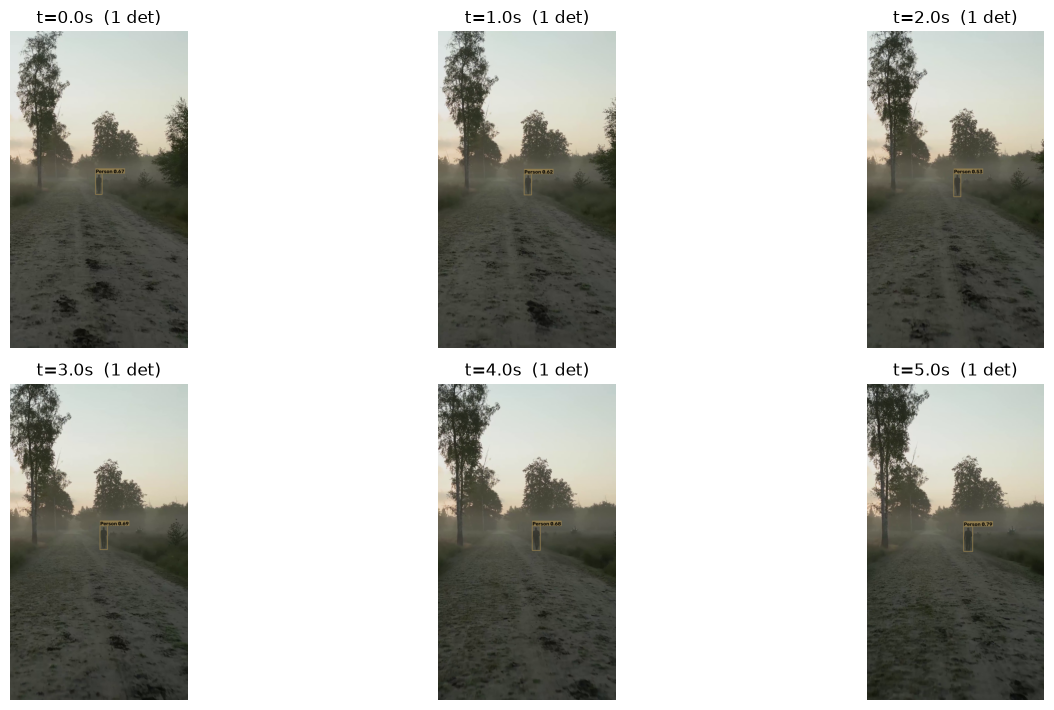

,count,mean_conf
class,,
Person,14,0.732755


In [8]:
if MEDIA_TYPE == "video":
    if previews:
        cols = 3
        rows = int(np.ceil(len(previews) / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 3.6 * rows))
        axes = np.atleast_1d(axes).ravel()
        for ax in axes:
            ax.axis("off")
        for ax, (t, n, fr) in zip(axes, previews):
            ax.imshow(bgr2rgb(fr))
            ax.set_title(f"t={t:.1f}s  ({n} det)")
        plt.tight_layout()
        plt.show()

    if len(det_df):
        display(det_df.groupby("class")["conf"].agg(["count", "mean"]).rename(columns={"mean": "mean_conf"}))
    else:
        print("No detections in any sampled frame.")

### Play the result inline (video only; needs the H.264 re-encode)

In [9]:
from IPython.display import Video, display

if MEDIA_TYPE == "video":
    size_mb = final_path.stat().st_size / 1e6
    if ffmpeg and size_mb < 100:
        display(Video(str(final_path), embed=True, width=800))
    else:
        print(f"Open the file directly: {final_path.resolve()}  ({size_mb:.1f} MB)")

Open the file directly: G:\Projects\Low Visibility\outputs\15365456-hd_1080_1920_30fps_detected.mp4  (33.8 MB)
